In [15]:
'''
ML Pipeline for Gridded Precip Project (XGBoost) - both IDW and kriging input options

Overview and Motivation
The goal of this workflow is to integrate heterogeneous observational, satellite, and climatological datasets into a unified, physically informed ML framework
for predicting precipitation phase (rain, snow, or mixed). Because direct precipitation-phase observations are sparse and unevenly distributed in space and time,
we adopt a weakly supervised labeling approach using an interpolated MRoS proxy, combined with spatially blocked ML training to handle prediction across complex terrain.

1. Gridded surface preprocessing
All predictor layers are aligned to a common coordinate reference system, grid resolution, and timestamp index.
Output: Stacked gridded predictor datasets (NetCDF), one layer per variable per hour.

2. Precip phase labeling via MRoS proxy
The interpolated MRoS proxy surface is converted into discrete phase classes
The MRoS proxy is used exclusively for labeling and is not included as a predictor to avoid target leakage.
Output: A space-time mask identifying gridcell-hours with usable phase labels.

3. Feature table construction:
Transform gridded data back into tabular format required for ML processing.
Output: a tabular dataset (e.g., parquet) suitable for ML training

4. Spatial blocking to split data
Motivation: spatial blocking accounts for spatial autocorrelation and avoids overestimated performance that arise from random splits.

5. ML model training
XGBoost binary classifier:
Target: predict rain or snow probabilities, and hiearchical structure determines if they're not decisive, label as mix.
Outputs class probabilities (& uncertainty)
Model hyperparameter tuning on validation set (tree depth, learning rate, subsampling, min_child_weight, etc.)
Stopping criteria via early stopping on validation loss

6. Model evaluation and performance
Model performance is evaluated on a fully held-out test set.
'''

"\nML Pipeline for Gridded Precip Project (XGBoost) - both IDW and kriging input options\n\nOverview and Motivation\nThe goal of this workflow is to integrate heterogeneous observational, satellite, and climatological datasets into a unified, physically informed ML framework\nfor predicting precipitation phase (rain, snow, or mixed). Because direct precipitation-phase observations are sparse and unevenly distributed in space and time,\nwe adopt a weakly supervised labeling approach using an interpolated MRoS proxy, combined with spatially blocked ML training to handle prediction across complex terrain.\n\n1. Gridded surface preprocessing\nAll predictor layers are aligned to a common coordinate reference system, grid resolution, and timestamp index.\nOutput: Stacked gridded predictor datasets (NetCDF), one layer per variable per hour.\n\n2. Precip phase labeling via MRoS proxy\nThe interpolated MRoS proxy surface is converted into discrete phase classes\nThe MRoS proxy is used exclusive

Key updates:
- removing overlapping air temp and dew temp variables from different data sources. Instead, introducing anomaly air temp and dew temp from PRISM compared to station data.
- thresholding update: implementing <=20 snow and >= rain... with remainder as mix. Introducing label confidence values.
- removing prism_ppt_daily
- including label confidence weights on top of existing class rebalancing. Also, transition-window upweight (focus on 0–4°C wet-bulb)
- replacing softmax multiclass training with binary training + abstention logic (binary snow vs rain probability model --> if probabilities aren’t decisive, label as mix/uncertain). This directly operationalizes the transition zone overlap idea: it’s not that mix is a third clean class, it’s often an inseparable region using surface meteorology

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import json
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.metrics import brier_score_loss
from scipy.stats import entropy


In [ ]:
BASE_DIR = Path().resolve().parent  # current working dir
print("BASE_DIR:", BASE_DIR)

ML_DIR = BASE_DIR / "ML_pipeline"
print("ML_DIR:", ML_DIR)

DATA_DIR = Path("C:/Users/EmmaGolub/Desktop/MRoS_local/local_data") # change to USER's local folder where large data files are stored
print("DATA_DIR:", DATA_DIR)

PATHS = {
    "IDW": DATA_DIR / "IDW/hourly_predictors_1km_IDW_full.nc",
    "kriging": DATA_DIR / "kriging/hourly_predictors_1km_kriging_v1_final.nc",
    "imerg": BASE_DIR / "outputs/resampled_grids/imerg_hourly_1km.nc",
    "prism": BASE_DIR / "outputs/resampled_grids/prism_hourly_1km.nc",
}

interp_type = "kriging" # "IDW" or "kriging"

if interp_type == "IDW":
    interp_type_folder = "withIDW_v3"
elif interp_type == "kriging":
    interp_type_folder = "withKriging_v3"

SETUP_DIR = DATA_DIR / "ML_pipeline/compiled_input_predictors" / interp_type_folder # save locally because large files
SETUP_DIR.mkdir(exist_ok=True)
print("SETUP_DIR:", SETUP_DIR)

MODEL_OUT_DIR = ML_DIR / "model_artifacts" / interp_type_folder
MODEL_OUT_DIR.mkdir(exist_ok=True)
print("MODEL_OUT_DIR:", MODEL_OUT_DIR)

GRAPHICS_DIR = MODEL_OUT_DIR / "graphics"
GRAPHICS_DIR.mkdir(exist_ok=True)
print("GRAPHICS_DIR:", GRAPHICS_DIR)


BASE_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype
ML_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline
DATA_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\local_data
SETUP_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\local_data\compiled_input_predictors\withKriging_v3
MODEL_OUT_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withKriging_v3
GRAPHICS_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withKriging_v3\graphics


## Step 1: Preprocessing & QAQC

### 1a: Load datasets
Load interpolated predictors (IDW/kriging), IMERG, and PRISM. Sync by time and grid before proceeding.


In [18]:
## Checking time synchronization -------------------------------------------------

ds_IDW = xr.open_dataset(PATHS["IDW"])
ds_kriging = xr.open_dataset(PATHS["kriging"])
ds_imerg = xr.open_dataset(PATHS["imerg"])
ds_prism = xr.open_dataset(PATHS["prism"])

for name, ds in {
    "IDW": ds_IDW,
    "kriging": ds_kriging,
    "IMERG": ds_imerg,
    "PRISM": ds_prism,
}.items():
    print(f"\n{name}")
    print(ds)

def summarize_time(ds, name):
    t = ds["time"]
    print(f"\n{name} time summary:")
    print("  start:", pd.to_datetime(t.values[0]))
    print("  end:  ", pd.to_datetime(t.values[-1]))
    print("  n:", t.size)
    print("  freq guess:", pd.infer_freq(pd.to_datetime(t.values[:10])))

summarize_time(ds_IDW, "IDW")
summarize_time(ds_kriging, "kriging")
summarize_time(ds_imerg, "IMERG")
summarize_time(ds_prism, "PRISM")



IDW
<xarray.Dataset> Size: 5GB
Dimensions:         (time: 5832, y: 251, x: 142)
Coordinates:
  * y               (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
  * x               (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * time            (time) datetime64[ns] 47kB 2024-10-01 ... 2025-05-31T23:0...
Data variables:
    temp_air        (time, y, x) float32 831MB ...
    temp_dew        (time, y, x) float32 831MB ...
    temp_wet        (time, y, x) float32 831MB ...
    rh              (time, y, x) float32 831MB ...
    mros_plp_proxy  (time, y, x) float32 831MB ...
    plp             (time, y, x) float32 831MB ...
    elev            (y, x) float32 143kB ...
    spatial_ref     int64 8B ...
Attributes:
    title:             Hourly predictor stacks on 1-km grid
    lapse_degC_per_m:  -0.005
    idw_power:         2.0
    k_nearest:         8
    GeoTransform:      162130.9182594687 1000.0 0.0 4426426.168783374 0.0 -10...

kriging
<xarray.Dataset> Size

In [19]:
# Assign interpolation type toggle

if interp_type == "IDW":
    ds_interp = ds_IDW
elif interp_type == "kriging":
    ds_interp = ds_kriging
else:
    raise ValueError(f"Unknown interp_type: {interp_type}")

In [20]:
# Synchronize times across datasets

common_times = np.intersect1d(
    ds_interp.time.values,
    ds_imerg.time.values
)
common_times = np.intersect1d(
    common_times,
    ds_prism.time.values
)

print(f"Common timesteps across IMERG, PRISM, and {interp_type}:",
      len(common_times))

ds_interp = ds_interp.sel(time=common_times)
ds_imerg = ds_imerg.sel(time=common_times)
ds_prism = ds_prism.sel(time=common_times)

Common timesteps across IMERG, PRISM, and kriging: 5160


### 1b. Check data

In [ ]:
# Check grid synchronization 

def summarize_grid(ds, name):
    print(f"\n{name} grid:")
    for dim in ["x", "y"]:
        if dim in ds.dims:
            vals = ds[dim].values
            print(f"  {dim}: n={len(vals)}, "
                  f"min={vals.min():.2f}, max={vals.max():.2f}, "
                  f"dx≈{np.mean(np.diff(vals)):.2f}")

summarize_grid(ds_interp, f"{interp_type}")
summarize_grid(ds_imerg, "IMERG")
summarize_grid(ds_prism, "PRISM")

# Checking general stats

def quick_stats(ds, var):
    v = ds[var]
    return {
        "min": float(v.min()),
        "max": float(v.max()),
        "nan_frac": float(v.isnull().mean())
    }

for var in ds_prism.data_vars:
    print("PRISM", var, quick_stats(ds_prism, var))

## Checking internal time counts/distribution

def time_qc(ds, name):
    t = pd.to_datetime(ds.time.values)
    print(f"\n{name} time QC:")
    print("  monotonic:", (np.diff(t.values) > np.timedelta64(0, "s")).all())
    print("  unique:", len(t) == len(np.unique(t)))
    # Check that all are on the hour
    print("  all on hour:", np.all(t.minute == 0) and np.all(t.second == 0))

    # Check per-day counts
    per_day_counts = pd.Series(1, index=t).resample("D").sum()
    print("  per-day count summary:")
    print(per_day_counts.describe())

time_qc(ds_interp, f"{interp_type}")
time_qc(ds_imerg, "IMERG")
time_qc(ds_prism, "PRISM")


## Checking some more stats -------------------------------------------------

def var_stats(ds, vars_, name):
    print(f"\n{name} value stats:")
    for v in vars_:
        da = ds[v]
        print(
            f"  {v}: "
            f"min={float(da.min()):.2f}, "
            f"max={float(da.max()):.2f}, "
            f"nan_frac={float(da.isnull().mean()):.4f}"
        )

var_stats(
    ds_interp,
    ["temp_air", "temp_dew", "temp_wet", "rh", "mros_plp_proxy"],
    interp_type
)
# TODO: FIX RH OUT OF BOUNDS

var_stats(ds_imerg, ["imerg_plp"], "IMERG")

var_stats(
    ds_prism,
    ["prism_tair", "prism_tmean", "prism_tdmean"],
    "PRISM"
)



kriging grid:
  x: n=142, min=162630.92, max=303630.92, dx≈1000.00
  y: n=251, min=4175926.17, max=4425926.17, dx≈-1000.00

IMERG grid:
  x: n=142, min=162630.92, max=303630.92, dx≈1000.00
  y: n=251, min=4175926.17, max=4425926.17, dx≈-1000.00

PRISM grid:
  x: n=142, min=162630.92, max=303630.92, dx≈1000.00
  y: n=251, min=4175926.17, max=4425926.17, dx≈-1000.00
PRISM prism_tair {'min': -26.73922626164204, 'max': 34.437614700831105, 'nan_frac': 0.0}
PRISM prism_tmean {'min': -16.262734494423775, 'max': 25.713881844107153, 'nan_frac': 0.0}
PRISM prism_tdmean {'min': -28.220525136197175, 'max': 15.807606480060583, 'nan_frac': 0.0}
PRISM prism_ppt {'min': 0.0, 'max': 179.0049390438019, 'nan_frac': 0.0}
PRISM spatial_ref {'min': 0.0, 'max': 0.0, 'nan_frac': 0.0}

kriging time QC:
  monotonic: True
  unique: True
  all on hour: True
  per-day count summary:
count    232.000000
mean      22.241379
std        6.267653
min        0.000000
25%       24.000000
50%       24.000000
75%       24

In [22]:
# Finally intersect times and commit to common period

common_times = np.intersect1d(
    ds_interp.time.values,
    ds_imerg.time.values
)
common_times = np.intersect1d(common_times, ds_prism.time.values)

ds_interp   = ds_interp.sel(time=common_times)
ds_imerg = ds_imerg.sel(time=common_times)
ds_prism = ds_prism.sel(time=common_times)

assert ds_interp.time.identical(ds_imerg.time)
assert ds_interp.time.identical(ds_prism.time)


## Step 2: Exploratory data analysis to confirm distributions of possible predictors
This section contains grouped plotting and diagnostic figures used to understand predictor distributions and phase relationships.

### Step 2a: General mros proxy distributions

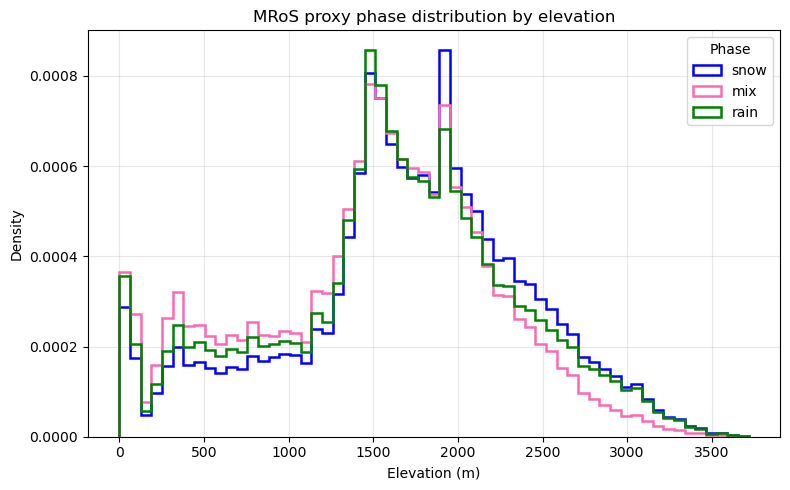

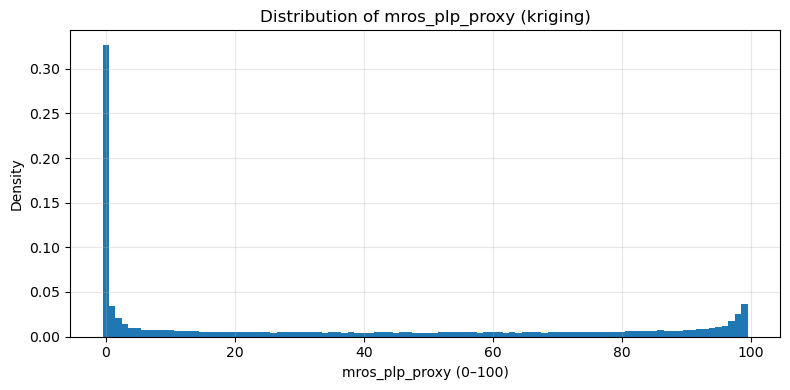

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_8216\2758387731.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_visualize2.groupby(["temp_bin", "proxy_cat"])


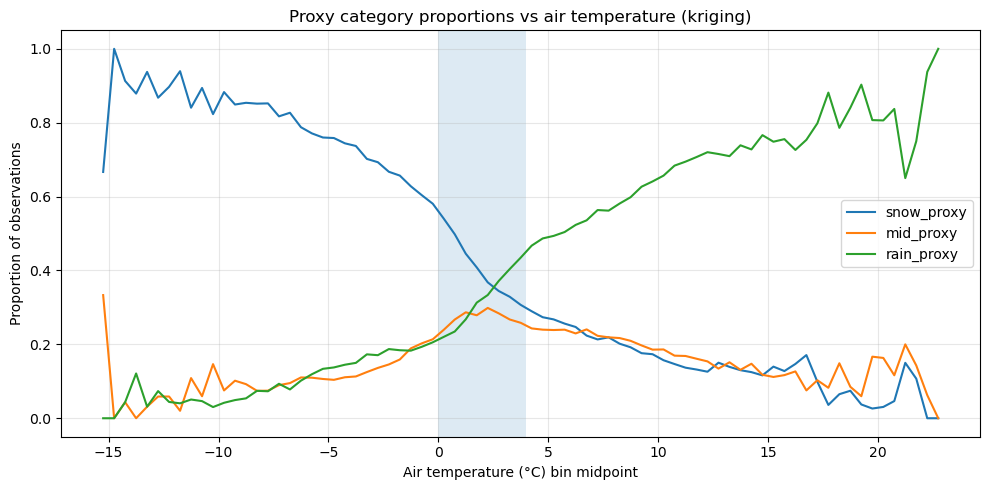

Overall mid-proxy fraction (20<proxy<80): 0.223


In [24]:
# 1) Find common time across datasets
common_time = np.intersect1d(
    np.intersect1d(ds_interp["time"].values, ds_imerg["time"].values),
    ds_prism["time"].values,
)

# 2) Coalesce dataset
eda_ds = xr.Dataset(
    {
        "temp_air":       ds_interp["temp_air"].sel(time=common_time),
        "temp_dew":       ds_interp["temp_dew"].sel(time=common_time),
        "temp_wet":       ds_interp["temp_wet"].sel(time=common_time),
        "rh":             ds_interp["rh"].sel(time=common_time),
        "mros_plp_proxy": ds_interp["mros_plp_proxy"].sel(time=common_time),
        "elev":           ds_interp["elev"],
        "imerg_plp":      ds_imerg["imerg_plp"].sel(time=common_time),
        "prism_tair":     ds_prism["prism_tair"].sel(time=common_time), # this is the diurnal hourly one
        "prism_tmean":    ds_prism["prism_tmean"].sel(time=common_time), # these are "hourly" in that their daily values were repeated 24 times
        "prism_tdmean":   ds_prism["prism_tdmean"].sel(time=common_time), # these are "hourly" in that their daily values were repeated 24 times
        "prism_ppt":      ds_prism["prism_ppt"].sel(time=common_time), # these are "hourly" in that their daily values were repeated 24 times


    },
    coords={"time": common_time, "y": ds_interp["y"], "x": ds_interp["x"]},
)

stacked = eda_ds.stack(sample=("time", "y", "x"))
df_visualize = stacked.to_dataframe().dropna(subset=["mros_plp_proxy"])

# MRoS proxy phase distribution by elevation ------------------------------------------------------
plt.figure(figsize=(8, 5))
bins = np.linspace(df_visualize["elev"].min(), df_visualize["elev"].max(), 60)
colors = {"snow": "blue", "mix": "#ff69b4", "rain": "green"}

phase_arr = np.where(
    df_visualize["mros_plp_proxy"] <= 20, 0,
    np.where(df_visualize["mros_plp_proxy"] >= 80, 2, 1)
)
df_visualize["phase"] = phase_arr

phase_name_map = {0: "snow", 1: "mix", 2: "rain"}
df_visualize["phase_name"] = df_visualize["phase"].map(phase_name_map)

for ph, name in phase_name_map.items():
    elev_vals = df_visualize.loc[df_visualize["phase"] == ph, "elev"].values
    if len(elev_vals) == 0:
        continue
    plt.hist(
        elev_vals,
        bins=bins,
        histtype="step",
        density=True,
        label=name,
        color=colors[name],
        linewidth=1.8,
    )

plt.xlabel("Elevation (m)")
plt.ylabel("Density")
plt.title("MRoS proxy phase distribution by elevation")
plt.legend(title="Phase")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Diagnose MRoS proxy distribution + proxy vs air temp -------------------------------------------------
df_visualize2 = stacked.to_dataframe().dropna(subset=["mros_plp_proxy", "temp_air"])

# Downsample for speed
max_samples = 300_000
if len(df_visualize2) > max_samples:
    df_visualize2 = df_visualize2.sample(n=max_samples, random_state=42)

# Overall proxy distribution
plt.figure(figsize=(8,4))
plt.hist(df_visualize2["mros_plp_proxy"].values, bins=np.arange(-0.5, 100.5, 1.0), density=True)
plt.xlabel("mros_plp_proxy (0–100)")
plt.ylabel("Density")
plt.title(f"Distribution of mros_plp_proxy ({interp_type})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Proxy category vs air temperature (proportion by temp bin)
df_visualize2["proxy_cat"] = np.where(df_visualize2["mros_plp_proxy"] <= 20, "snow_proxy",
                   np.where(df_visualize2["mros_plp_proxy"] >= 80, "rain_proxy", "mid_proxy"))

# Temperature bins
bin_width = 0.5
tmin = np.floor(df_visualize2["temp_air"].min())
tmax = np.ceil(df_visualize2["temp_air"].max())
bins = np.arange(tmin, tmax + bin_width, bin_width)

df_visualize2["temp_bin"] = pd.cut(df_visualize2["temp_air"], bins=bins, include_lowest=True)

prop = (
    df_visualize2.groupby(["temp_bin", "proxy_cat"])
      .size()
      .unstack(fill_value=0)
)
prop = prop.div(prop.sum(axis=1), axis=0)

# Make x-axis numeric
bin_mids = np.array([b.mid for b in prop.index.categories])
prop = prop.reindex(prop.index.categories)  # ensure consistent ordering

plt.figure(figsize=(10,5))
for cat in ["snow_proxy", "mid_proxy", "rain_proxy"]:
    if cat in prop.columns:
        plt.plot(bin_mids, prop[cat].values, label=cat)

plt.axvspan(0, 4, alpha=0.15)  # highlight the difficult window
plt.xlabel("Air temperature (°C) bin midpoint")
plt.ylabel("Proportion of observations")
plt.title(f"Proxy category proportions vs air temperature ({interp_type})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Quick check: what fraction are 'mid_proxy' overall?
mid_frac = (df_visualize2["proxy_cat"] == "mid_proxy").mean()
print(f"Overall mid-proxy fraction (20<proxy<80): {mid_frac:.3f}")


### 2b. Predictor marginal distributions (1D density histograms)

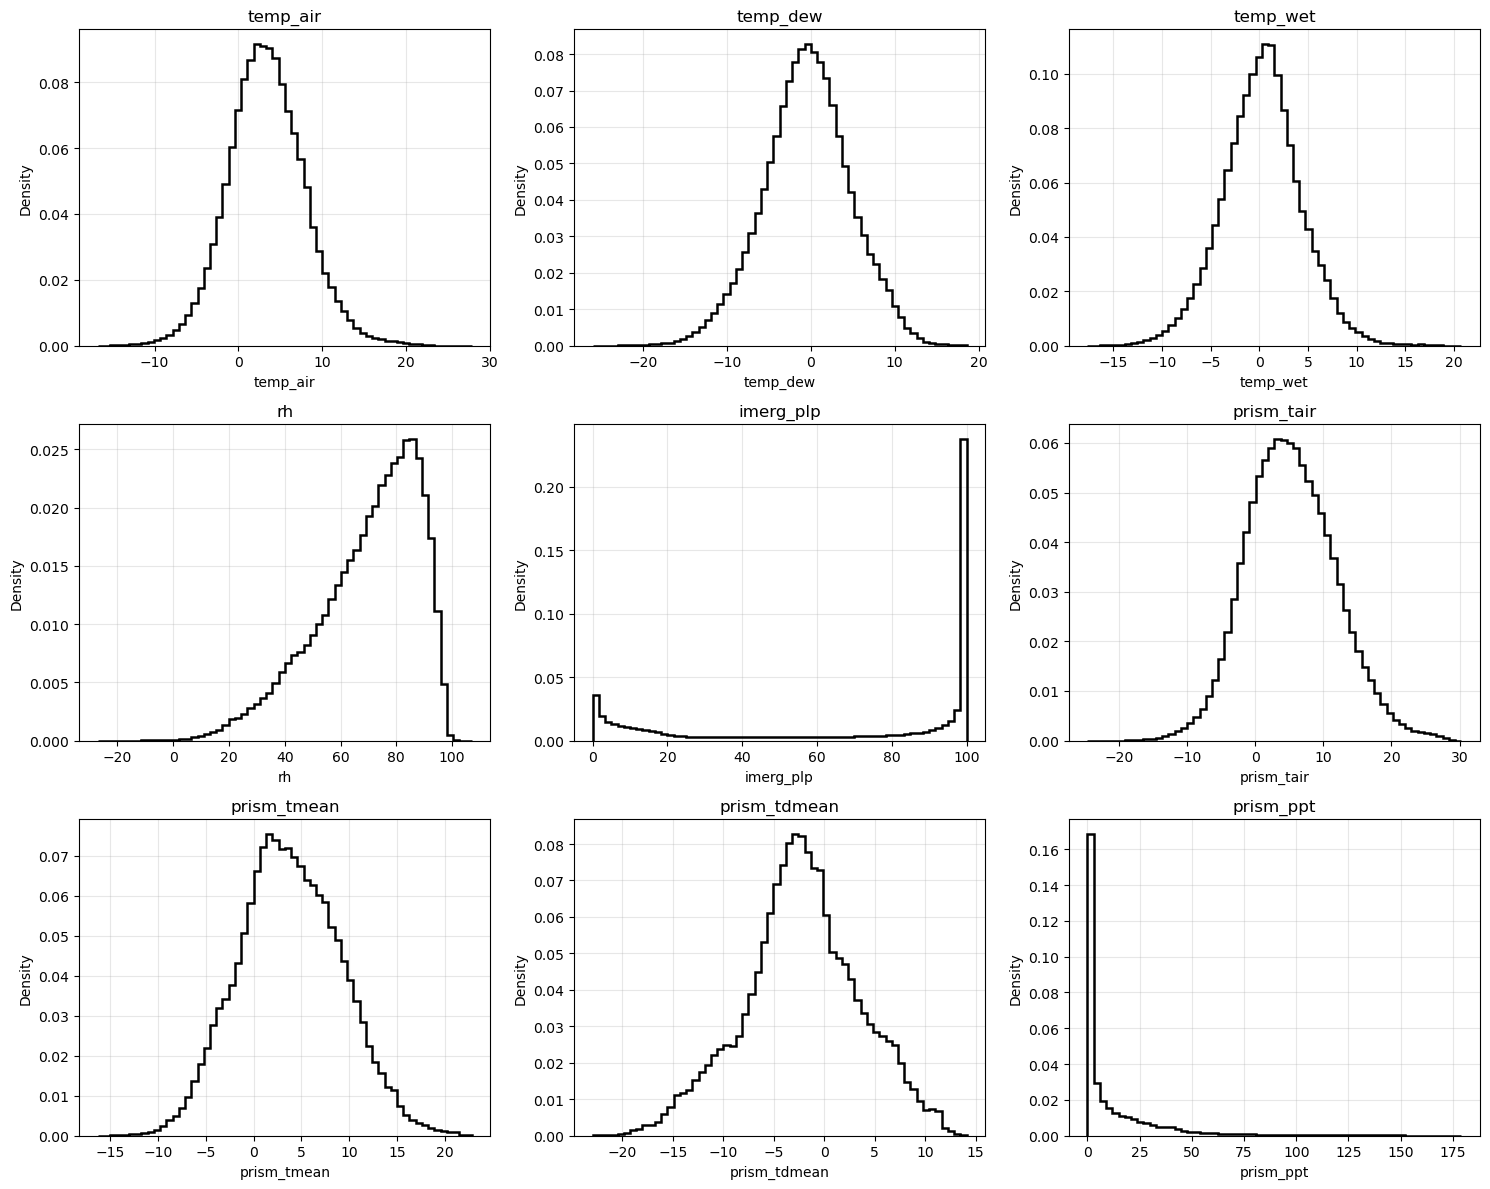

In [26]:
predictors_plotting = [
    "temp_air",
    "temp_dew",
    "temp_wet",
    "rh",
    "imerg_plp",
    "prism_tair",
    "prism_tmean",
    "prism_tdmean",
    "prism_ppt",
]

n_vars = len(predictors_plotting)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
)
axes = axes.ravel()

for ax, var in zip(axes, predictors_plotting):
    vals = df_visualize[var].dropna().values
    if len(vals) == 0:
        ax.set_visible(False)
        continue

    ax.hist(
        vals,
        bins=60,
        density=True,
        histtype="step",
        linewidth=1.8,
        color="black",
    )

    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("Density")
    ax.grid(alpha=0.3)

for ax in axes[n_vars:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


### 2c. Elevation × wet-bulb temperature phase frequency

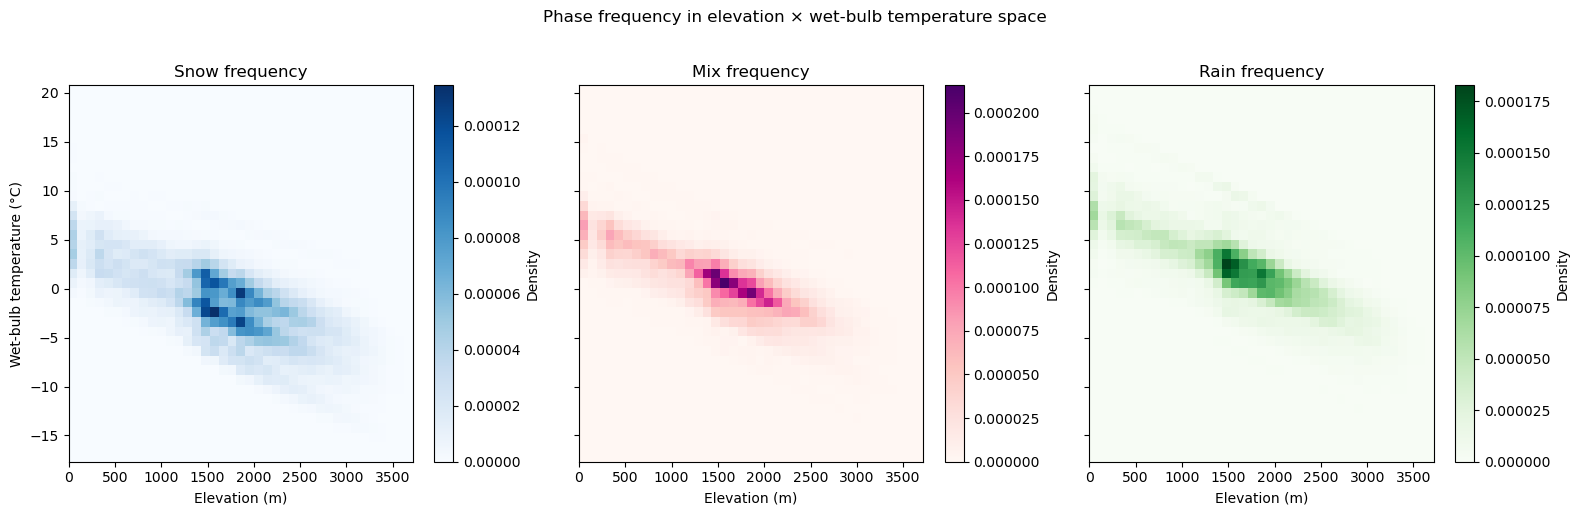

In [27]:
# Bin definitions
elev_bins = np.linspace(df_visualize["elev"].min(), df_visualize["elev"].max(), 40)
tw_bins   = np.linspace(df_visualize["temp_wet"].min(), df_visualize["temp_wet"].max(), 40)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

phase_labels = {0: "Snow", 1: "Mix", 2: "Rain"}
phase_colors = {0: "Blues", 1: "RdPu", 2: "Greens"}

for ax, ph in zip(axes, [0, 1, 2]):
    sub = df_visualize[df_visualize["phase"] == ph]
    h, xedges, yedges = np.histogram2d(
        sub["elev"],
        sub["temp_wet"],
        bins=[elev_bins, tw_bins],
        density=True,
    )

    im = ax.pcolormesh(
        xedges,
        yedges,
        h.T,
        cmap=phase_colors[ph],
        shading="auto",
    )

    ax.set_title(f"{phase_labels[ph]} frequency")
    ax.set_xlabel("Elevation (m)")
    if ax is axes[0]:
        ax.set_ylabel("Wet-bulb temperature (°C)")

    plt.colorbar(im, ax=ax, label="Density")

fig.suptitle("Phase frequency in elevation × wet-bulb temperature space", y=1.02)
plt.tight_layout()
plt.show()


### 2d. IMERG PLP vs MRoS phase distribution

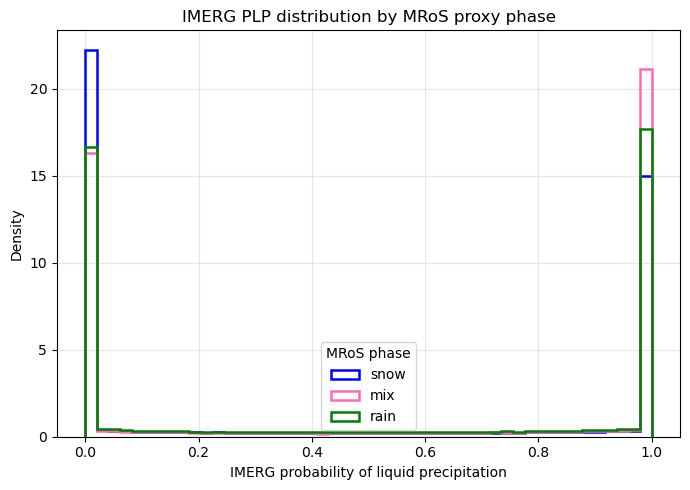

In [28]:
plt.figure(figsize=(7, 5))

for ph, name in phase_name_map.items():
    sub = df_visualize[df_visualize["phase"] == ph]

    plt.hist(
        sub["imerg_plp"],
        bins=np.linspace(0, 1, 50),
        density=True,
        histtype="step",
        linewidth=1.8,
        label=name,
        color=colors[name],
    )

plt.xlabel("IMERG probability of liquid precipitation")
plt.ylabel("Density")
plt.title("IMERG PLP distribution by MRoS proxy phase")
plt.legend(title="MRoS phase")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 2e.  Violin plots: predictor distributions by elevation band

KeyboardInterrupt: 

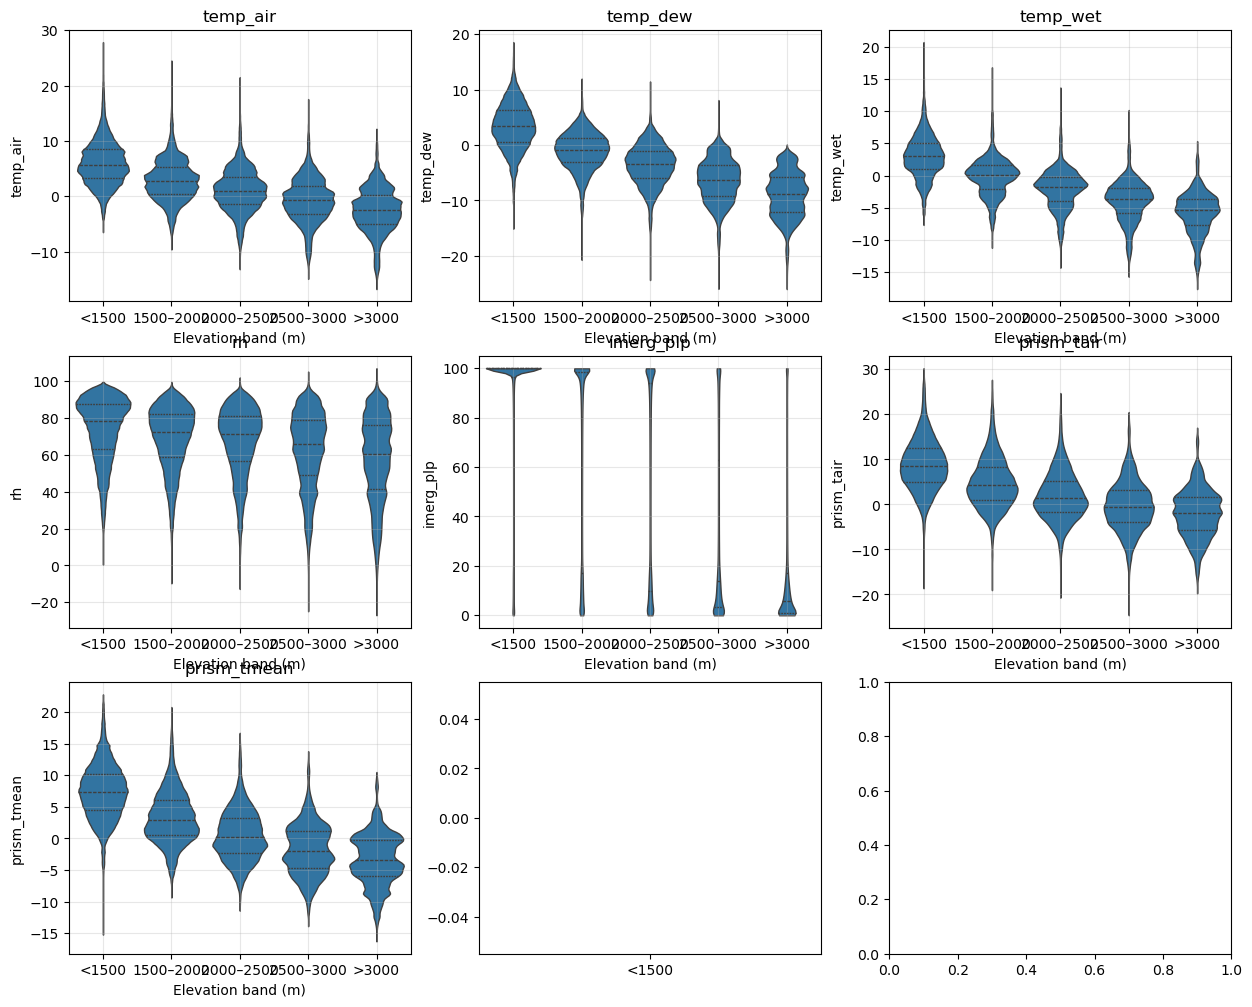

In [ ]:
cols_for_viz = ["elev"] + predictors_plotting

df_visualize = df_visualize[cols_for_viz].copy()
# IMPORTANT: drop the MultiIndex completely, do NOT turn it into columns
df_visualize = df_visualize.reset_index(drop=True)

# Define elevation bands
elev_bins = [0, 1500, 2000, 2500, 3000, np.inf]
elev_labels = ["<1500", "1500–2000", "2000–2500", "2500–3000", ">3000"]

df_visualize["elev_band"] = pd.cut(
    df_visualize["elev"],
    bins=elev_bins,
    labels=elev_labels,
    include_lowest=True,
)

n_vars = len(predictors_plotting)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharex=False,
)
axes = axes.ravel()

for ax, var in zip(axes, predictors_plotting):
    sub = df_visualize[["elev_band", var]].dropna()
    if sub.empty:
        ax.set_visible(False)
        continue

    sns.violinplot(
        data=sub,
        x="elev_band",
        y=var,
        ax=ax,
        inner="quartile",
        cut=0,
        linewidth=1,
    )

    ax.set_title(var)
    ax.set_xlabel("Elevation band (m)")
    ax.set_ylabel(var)
    ax.grid(alpha=0.3)

# Hide any unused axes
for ax in axes[n_vars:]:
    ax.set_visible(False)

fig.suptitle("Predictor distributions by elevation band (pre-ML)", y=0.92)
plt.tight_layout()
plt.show()


## Step 3: Labeling & Confidence Masking

Create phase labels from the MRoS proxy and apply confidence masks to filter unreliable gridcell-hours prior to ML extraction.


In [ ]:
# Label thresholding: treat proxy as noisy probability surface snow if proxy <= 20, rain if proxy >= 80, else unlabeled for training

proxy = ds_interp["mros_plp_proxy"]

# Binary labels only where confident
phase = xr.where(proxy <= 20, 0,
             xr.where(proxy >= 80, 1, np.nan))
# # Another version:
# phase = xr.where(proxy <= 40, 0,
#              xr.where(proxy >= 60, 1, np.nan))
# Another version: optimize this threshold based on mros_plp_proxy distribution

# Label confidence: distance from 50% (0 at 50, 1 at 0/100). This is grounded in the idea that mid-proxy values are inherently ambiguous.
label_confidence = np.abs(proxy - 50.0) / 50.0
label_confidence = label_confidence.clip(0.0, 1.0)

# Binary mask: only keep confident samples
label_mask_bin = xr.where(np.isfinite(phase), True, False)

# Create mask to enforce valid samples... 
# Not all gridcell hours are reliable from MRoS proxy (it's not actually ground truth; some estimates may be low confidence) or IMERG (many hours are non-precipitating).
label_mask = (
    ds_interp["mros_plp_proxy"].notnull() &
    (ds_imerg["imerg_plp"] > 0.05)
)

label_mask_final = label_mask & label_mask_bin

labels = xr.Dataset(
    {
        "phase": phase,
        "label_confidence": label_confidence,
        "label_mask_bin": label_mask_bin,
        "label_mask": label_mask_final,  # overwrite to enforce binary-valid samples
        "mros_plp_proxy": proxy,         # keep for diagnostics
    },
    coords=ds_interp.coords
)

# Save labels
if interp_type == "IDW":
    out_labels = SETUP_DIR / "labels_phase_hourly_1km_withIDW.nc"
elif interp_type == "kriging":
    out_labels = SETUP_DIR / "labels_phase_hourly_1km_withKriging.nc"
else:
    raise ValueError(f"Unknown interp_type: {interp_type}")

labels.to_netcdf(
    out_labels,
    encoding={
        "phase": {"zlib": True},
        "label_confidence": {"zlib": True},
        "label_mask": {"zlib": True},
        "mros_plp_proxy": {"zlib": True},
    }
)
print("Saved labels to:", out_labels)



# TODO: if deploying on larger grids / more time, consider masking to precip > threshold first, since right now our model is training only in precipitation conditions (no experience with dry hours)


Saved labels to: C:\Users\EmmaGolub\Desktop\MRoS_local\local_data\compiled_input_predictors\withKriging_v3\labels_phase_hourly_1km_withKriging.nc


## Step 4. Predictors set up / tabular extraction

In [31]:
# Build one xarray dataset containing only the predictors

predictors = xr.Dataset(
    {
        # IDW / kriging (ds_interp)
        "temp_air": ds_interp["temp_air"],
        "temp_dew": ds_interp["temp_dew"],
        "temp_wet": ds_interp["temp_wet"],
        "rh": ds_interp["rh"],

        # IMERG
        "imerg_plp": ds_imerg["imerg_plp"],

        # PRISM
        "prism_tair": ds_prism["prism_tair"],
        "prism_tmean": ds_prism["prism_tmean"],
        "prism_tdmean": ds_prism["prism_tdmean"],

        # ANOMOLIES (signal + discrepancy)
        "t_air_anom": ds_interp["temp_air"] - ds_prism["prism_tair"],

        # Static
        "elev": ds_interp["elev"],
    },
    coords={
        "time": ds_interp.time,
        "x": ds_interp.x,
        "y": ds_interp.y,
    }
)

vars_keep = [
    "temp_dew",
    "temp_wet",
    "rh",
    "imerg_plp",
    "t_air_anom",
    "elev",
]
predictors = predictors[vars_keep]
print(predictors)

if interp_type == "IDW":
    out_nc = SETUP_DIR / "predictors_hourly_1km_withIDW.nc"
elif interp_type == "kriging":
    out_nc = SETUP_DIR / "predictors_hourly_1km_withKriging.nc"
else:
    raise ValueError(f"Unknown interp_type: {interp_type}")

predictors.to_netcdf(
    out_nc,
    encoding={v: {"zlib": True, "complevel": 4} for v in predictors.data_vars}
)

print("Saved input predictor stack")

<xarray.Dataset> Size: 5GB
Dimensions:     (time: 5160, y: 251, x: 142)
Coordinates:
  * y           (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
  * x           (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * time        (time) datetime64[ns] 41kB 2024-10-11 ... 2025-05-30T23:00:00
Data variables:
    temp_dew    (time, y, x) float32 736MB 9.045 9.045 9.045 ... -4.634 9.782
    temp_wet    (time, y, x) float32 736MB 17.66 17.66 17.66 ... 8.915 19.41
    rh          (time, y, x) float32 736MB 24.53 24.47 24.4 ... 12.44 18.27
    imerg_plp   (time, y, x) float64 1GB 100.0 100.0 100.0 ... 100.0 100.0 100.0
    t_air_anom  (time, y, x) float64 1GB 12.6 13.11 14.86 ... 8.913 9.347 24.97
    elev        (y, x) float32 143kB ...
Saved input predictor stack


In [32]:
# Parquets will be much faster to use in ML... convert aligned gridded predictors + labels into a single, analysis-ready tabular dataset, apply label masking, assign spatial blocks, and write to Parquet once.

# Check label mask
label_mask = labels["label_mask"]
mask_frac = float(label_mask.mean())
print(f"Fraction of gridcell-hours kept: {mask_frac:.3f}")

# Reshaping/stacking to convert each (time, x, y) gridcell into one ML sample
predictors_stacked = predictors.stack(sample=("time", "y", "x"))
labels_stacked     = labels.stack(sample=("time", "y", "x"))
mask_stacked       = label_mask.stack(sample=("time", "y", "x"))

# Apply confidence mask after stacking to remove entire samples that fail label validity criteria. This helps ensure that every retained sample has a usable phase label. Also reduces dataset size to enhance label quality.
predictors_valid = predictors_stacked.where(mask_stacked, drop=True)
labels_valid     = labels_stacked.where(mask_stacked, drop=True)

Fraction of gridcell-hours kept: 0.101


At this point:
- every remaining row has a valid phase label
- no NaN label rows survive

In [33]:
# ML libraries require 2D tabular inputs, so convert to pandas:
X = predictors_valid.to_dataframe()
y = labels_valid[["phase", "label_confidence"]].to_dataframe()[["phase", "label_confidence"]]  # phase target + confidence

# Identify index names (these will be inserted by reset_index) and enforce uniqueness prior to flattening
index_cols = X.index.names 

# Master dataframe of reshaped gridcell-time samples with mask applied; contains predictor columns
master_df = (
    X.drop(columns=index_cols, errors="ignore")
     .join(y, how="inner")
     .reset_index()
)

print(master_df.columns)
assert master_df.columns.duplicated().sum() == 0

# Check class balance (by phase)
master_df["phase"].value_counts(normalize=True)

Index(['time', 'y', 'x', 'temp_dew', 'temp_wet', 'rh', 'imerg_plp',
       't_air_anom', 'elev', 'phase', 'label_confidence'],
      dtype='object')


phase
1.0    0.512739
0.0    0.487261
Name: proportion, dtype: float64

Now each row is a single gridcell at a single hour.
- Predictor columns
- Target phase column
- Spatiotemporal metadata columns (x, y, time)

## Step 5: Spatial Blocking

### 5a: Defining spatial blocks
Motivation: Standard random cross-validation grossly overestimates ML skill when data are spatially autocorrelated.
Guiding literature: Stock & Subramaniam (2022); https://doi.org/10.1080/15481603.2022.2107113
- Random splits allow near-duplicate information to leak across train/test
- Reported accuracy becomes meaningless for true spatial generalization

In our case, neighboring gridcells share:
- elevation
- meteorology
- storm structure
Random CV would dramatically overestimate phase-prediction skill

Each row = one labeled gridcell-hour

Predictors:
- station temp_wet, rh,
- imerg_plp,
- T_anom and Td_anom (|STATION - PRISM|)
- elev

metadata: time, x, y, block_id

In [34]:
BLOCK_SIZE_M = 25_000

master_df["block_x"] = (master_df["x"] // BLOCK_SIZE_M).astype(np.int32)
master_df["block_y"] = (master_df["y"] // BLOCK_SIZE_M).astype(np.int32)

master_df["block_id"] = list(zip(master_df["block_x"], master_df["block_y"]))

print(master_df["block_id"].nunique(), "unique spatial blocks")

master_df["block_id"].value_counts().describe()

77 unique spatial blocks


count        77.000000
mean     241025.831169
std      124029.763957
min        2048.000000
25%      161347.000000
50%      306556.000000
75%      335126.000000
max      378434.000000
Name: count, dtype: float64

In [35]:
# Drop tiny blocks
block_counts = master_df["block_id"].value_counts()

keep_blocks = block_counts[block_counts >= 25_000].index
master_df = master_df[master_df["block_id"].isin(keep_blocks)].copy()

print("Blocks kept:", master_df["block_id"].nunique())
master_df["block_id"].value_counts().describe()


Blocks kept: 70


count        70.000000
mean     264063.114286
std      104975.066572
min       46702.000000
25%      169527.750000
50%      311961.000000
75%      335954.500000
max      378434.000000
Name: count, dtype: float64

### 5b: Random Block Splitting

Starting with single-partition spatial holdout validation (random block split). 
Can try full iterative spatial leave-one-out-cross-validation (SLOO-CV) later.

In [36]:
# Extract unique blocks and shuffle
# 
rng = np.random.default_rng(42)

blocks = master_df["block_id"].unique()
rng.shuffle(blocks)

n_blocks = len(blocks)
print("Total blocks:", n_blocks)


Total blocks: 70


### 5c. Define train/val/test split sizes

In [37]:
# Define split sizes (70 / 15/ 15)
n_train = int(0.70 * n_blocks)
n_val   = int(0.15 * n_blocks)

train_blocks = set(blocks[:n_train])
val_blocks   = set(blocks[n_train:n_train + n_val])
test_blocks  = set(blocks[n_train + n_val:])

assert train_blocks.isdisjoint(val_blocks)
assert train_blocks.isdisjoint(test_blocks)
assert val_blocks.isdisjoint(test_blocks)

print(len(train_blocks), len(val_blocks), len(test_blocks))

49 10 11


In [38]:
# Assign split labels to rows

def assign_split(bid):
    if bid in train_blocks:
        return "train"
    elif bid in val_blocks:
        return "val"
    else:
        return "test"

# This master_df master table is now the bridge between ML space and geophysical space.
master_df["split"] = master_df["block_id"].map(assign_split)

assert master_df["split"].notna().all()
print(master_df["split"].value_counts(normalize=True))

split
train    0.693012
test     0.160654
val      0.146334
Name: proportion, dtype: float64


In [39]:
# Check class balance diagnostics
phase_map = {0: "snow", 1: "rain"}

overall = (
    master_df["phase"]
    .value_counts(normalize=True)
    .rename(index=phase_map)
)

print("Overall class balance:")
print(overall)

by_split = (
    master_df.groupby("split")["phase"]
      .value_counts(normalize=True)
      .rename(index=phase_map)
      .unstack()
)

print("Class balance by split:")
print(by_split)


Overall class balance:
phase
rain    0.51252
snow    0.48748
Name: proportion, dtype: float64
Class balance by split:
phase      rain      snow
split                    
test   0.523943  0.476057
train  0.506783  0.493217
val    0.527149  0.472851


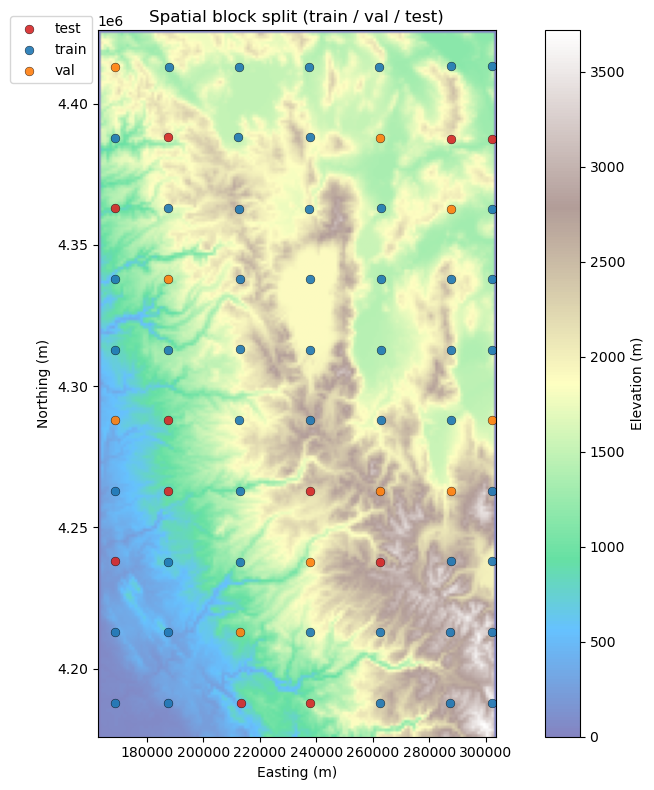

split
test      2969590
train    12809927
val       2704901
Name: n_samples, dtype: int64

In [40]:
# Visualize spatial block split over DEM

# Select DEM
dem = ds_interp["elev"]  # our DEM exists in any of the interpolated datasets

# Handle nodata if present
dem_vals = dem.values
if "_FillValue" in dem.attrs:
    dem_vals = np.where(dem_vals == dem.attrs["_FillValue"], np.nan, dem_vals)

# Compute spatial extent from coords
extent = [
    float(dem["x"].min()),
    float(dem["x"].max()),
    float(dem["y"].min()),
    float(dem["y"].max())
]

# Decide origin based on y direction
if float(dem["y"][0]) > float(dem["y"][-1]):
    # y decreases from north to south → put row 0 at the top (max y)
    origin = "upper"
else:
    origin = "lower"

# Spatial diagnostics
block_df = (
    master_df.groupby("block_id")
      .agg(
          x_mean=("x", "mean"),
          y_mean=("y", "mean"),
          split=("split", "first"),
          n=("phase", "size")
      )
      .reset_index()
)

colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:red"}

fig, ax = plt.subplots(figsize=(10, 8))

# DEM underlay
im = ax.imshow(
    dem_vals,
    extent=extent,
    origin=origin,
    cmap="terrain",
    alpha=0.6
)

# Block centroids
for split, g in block_df.groupby("split"):
    ax.scatter(
        g["x_mean"], g["y_mean"],
        s=40,
        c=colors[split],
        label=split,
        alpha=0.9,
        edgecolor="k",
        linewidths=0.3
    )

ax.legend(
    loc="upper left",
    bbox_to_anchor=(-0.22, 1.02),  # left of axes, slightly above
    frameon=True,
    borderaxespad=0.0
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Spatial block split (train / val / test)")
ax.set_aspect("equal")

cbar = fig.colorbar(im, ax=ax, label="Elevation (m)")
fig.tight_layout()
fig.savefig(GRAPHICS_DIR / f"spatial_block_split_{interp_type}.png", dpi=200, bbox_inches="tight")
plt.show()

master_df.groupby("split").size().rename("n_samples")

## Step 6: XGBoost Model Architecture

Gradient-boosted decision trees for binary logistic regression.

Structurally:

- The model is an ensemble of decision trees.
- Each tree is shallow (max_depth = 6).
- Trees are added sequentially.
- Each new tree corrects the residual errors of the previous ensemble.
- Minimizing the weighted binary cross entropy (log loss)

### Prepare features, target, train, val, and testing datasets + uncertainties

In [41]:
FEATURES = [
    # station-interpolated thermo
    "temp_wet", "temp_dew", "rh",

    # precip products
    "imerg_plp",

    # topography
    "elev",

    # discrepancy features (capturing station and PRISM datasets)
    "t_air_anom",
]

TARGET = "phase"  # 0=snow, 1=rain

# Prepare matrices
X_train = master_df.loc[master_df["split"] == "train", FEATURES]
y_train = master_df.loc[master_df["split"] == "train", TARGET].astype(int)

X_val   = master_df.loc[master_df["split"] == "val", FEATURES]
y_val   = master_df.loc[master_df["split"] == "val", TARGET].astype(int)

X_test  = master_df.loc[master_df["split"] == "test", FEATURES]
y_test  = master_df.loc[master_df["split"] == "test", TARGET].astype(int)

# Pull label confidence too!
c_train = master_df.loc[master_df["split"] == "train", "label_confidence"].values
c_val   = master_df.loc[master_df["split"] == "val",   "label_confidence"].values
c_test  = master_df.loc[master_df["split"] == "test",  "label_confidence"].values


### Class weighting to handle imbalance

In [ ]:
# Handle class imbalance... compute class weights from training set

# Binary classes
classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.values
)
class_weight = dict(zip(classes, weights))
print("Class weights:", class_weight)

# Base weights from class imbalance
w_train = y_train.map(class_weight).values
w_val   = y_val.map(class_weight).values

# Multiply by label confidence
w_train = w_train * c_train
w_val   = w_val * c_val

# Transition-window upweight: emphasize 0–4°C wet-bulb
alpha = 1.0  # start with 1.0; tune later (0.5–2.0 is a reasonable range)
tw_train = master_df.loc[master_df["split"] == "train", "temp_wet"].values
tw_val   = master_df.loc[master_df["split"] == "val",   "temp_wet"].values

transition_train = ((tw_train >= 0.0) & (tw_train <= 4.0)).astype(float)
transition_val   = ((tw_val   >= 0.0) & (tw_val   <= 4.0)).astype(float)

w_train = w_train * (1.0 + alpha * transition_train)
w_val   = w_val   * (1.0 + alpha * transition_val)

sample_weight_train = w_train
sample_weight_val   = w_val

Class weights: {np.int64(0): np.float64(1.013753331912013), np.int64(1): np.float64(0.9866148489384703)}


### Train!

[0]	train-logloss:0.67935	val-logloss:0.67898
[50]	train-logloss:0.47422	val-logloss:0.49987
[100]	train-logloss:0.44815	val-logloss:0.47854
[150]	train-logloss:0.43790	val-logloss:0.47057
[200]	train-logloss:0.43112	val-logloss:0.46559
[250]	train-logloss:0.42618	val-logloss:0.46192
[300]	train-logloss:0.42154	val-logloss:0.45850
[350]	train-logloss:0.41776	val-logloss:0.45570
[400]	train-logloss:0.41363	val-logloss:0.45292
[450]	train-logloss:0.40982	val-logloss:0.45038
[500]	train-logloss:0.40609	val-logloss:0.44795
[550]	train-logloss:0.40275	val-logloss:0.44582
[600]	train-logloss:0.40015	val-logloss:0.44406
[650]	train-logloss:0.39739	val-logloss:0.44248
[700]	train-logloss:0.39513	val-logloss:0.44117
[750]	train-logloss:0.39238	val-logloss:0.43946
[800]	train-logloss:0.38970	val-logloss:0.43803
[850]	train-logloss:0.38718	val-logloss:0.43649
[900]	train-logloss:0.38431	val-logloss:0.43460
[950]	train-logloss:0.38233	val-logloss:0.43333
[1000]	train-logloss:0.38016	val-logloss:0.

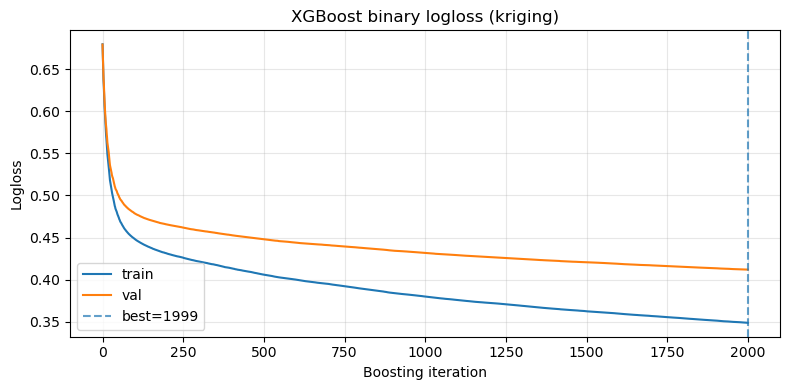

In [ ]:
# ~20 minutes to run

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 6, # controls tree complexity; prevents overfitting
    "eta": 0.05, # shrinks tree contribution; slower learning; more stable prob estimates
    "subsample": 0.8, # random row sampling per tree; reduces overfitting
    "colsample_bytree": 0.8, # random feature sampling per tree; reduces correlated feature dominance
    "min_child_weight": 5, # prevents splits on very small sample subsets
    "lambda": 1.0, # L2 regularization; penalizes large leaf weights
    "tree_method": "hist", # uses histogram-based algorithm for faster training
    "seed": 42,
}

dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weight_train)
dval   = xgb.DMatrix(X_val,   label=y_val,   weight=sample_weight_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)

evals = [(dtrain, "train"), (dval, "val")]
evals_result = {}

booster = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=evals,
    evals_result=evals_result,
    early_stopping_rounds=50, # training stops when validation logloss hasn't improved for 50 rounds
    verbose_eval=50,
)

# Loss curves
train_loss = evals_result["train"]["logloss"]
val_loss   = evals_result["val"]["logloss"]

plt.figure(figsize=(8,4))
plt.plot(train_loss, label="train")
plt.plot(val_loss, label="val")
plt.axvline(booster.best_iteration, ls="--", alpha=0.7, label=f"best={booster.best_iteration}")
plt.xlabel("Boosting iteration")
plt.ylabel("Logloss")
plt.title(f"XGBoost binary logloss ({interp_type})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Predict probabilities on test set

In [ ]:
# Abstention rate: allows to treat the model’s uncertainty region as operationally equivalent to mixed or uncertain phase.

# PREDICT PROBABILITIES ON TEST SET
p_rain = booster.predict(dtest)          # P(class=1)
p_snow = 1.0 - p_rain
max_prob = np.maximum(p_rain, p_snow)

# Abstention rule -> "mix/uncertain" if max(prob) < 0.6
# This is the fraction of samples where the model refuses to make a confident snow/rain decision.
abstain_thresh = 0.6
y_pred_abst = np.where(
    max_prob < abstain_thresh,
    2,  # 2 = mix/uncertain
    (p_rain >= 0.5).astype(int)  # 0 snow, 1 rain
)

# Report abstention rate + accuracy on non-abstained
abstain_rate = np.mean(y_pred_abst == 2)
mask_keep = (y_pred_abst != 2)
acc_keep = np.mean((y_pred_abst[mask_keep] == y_test.values[mask_keep])) if mask_keep.any() else np.nan

print(f"Abstention rate (mix/uncertain): {abstain_rate:.3f}")
print(f"Accuracy on non-abstained samples: {acc_keep:.3f} (n={mask_keep.sum()})")

print("\nConfusion matrix (non-abstained only; rows=true [snow,rain], cols=pred [snow,rain]):")
print(confusion_matrix(y_test.values[mask_keep], y_pred_abst[mask_keep], labels=[0,1]))

print("\nClassification report (non-abstained only):")
print(classification_report(y_test.values[mask_keep], y_pred_abst[mask_keep], labels=[0,1], target_names=["snow","rain"]))


Abstention rate (mix/uncertain): 0.121
Accuracy on non-abstained samples: 0.859 (n=2609517)

Confusion matrix (non-abstained only; rows=true [snow,rain], cols=pred [snow,rain]):
[[1063392  172313]
 [ 196128 1177684]]

Classification report (non-abstained only):
              precision    recall  f1-score   support

        snow       0.84      0.86      0.85   1235705
        rain       0.87      0.86      0.86   1373812

    accuracy                           0.86   2609517
   macro avg       0.86      0.86      0.86   2609517
weighted avg       0.86      0.86      0.86   2609517



## Prelim model evaluation:

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_8216\3123550546.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_test.groupby("tw_bin")["abstain"]


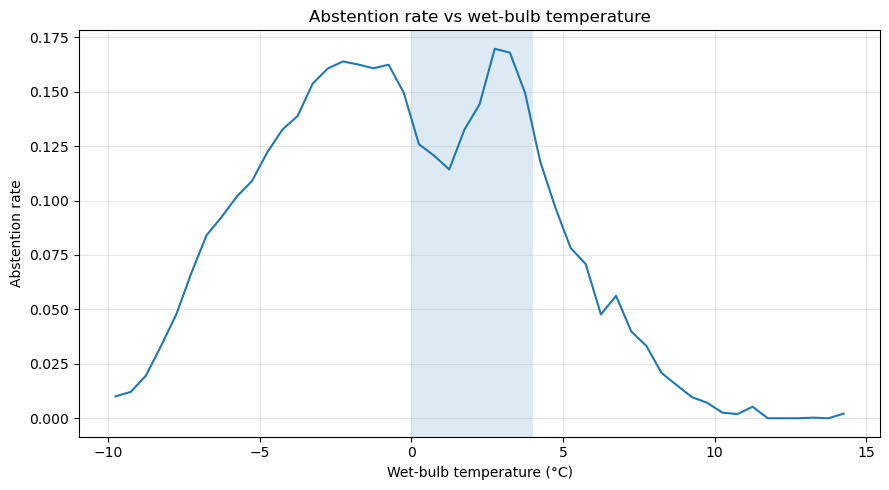

In [45]:
# Analyze abstention by wet-bulb bin

df_test = master_df.loc[master_df["split"] == "test"].copy()
df_test["p_rain"] = p_rain
df_test["p_snow"] = p_snow
df_test["max_prob"] = max_prob
df_test["abstain"] = (max_prob < abstain_thresh)

# Bin wet-bulb
bins = np.arange(-10, 15, 0.5)
df_test["tw_bin"] = pd.cut(df_test["temp_wet"], bins=bins)

abstain_rate_by_tw = (
    df_test.groupby("tw_bin")["abstain"]
    .mean()
)

bin_mids = np.array([b.mid for b in abstain_rate_by_tw.index.categories])

plt.figure(figsize=(9,5))
plt.plot(bin_mids, abstain_rate_by_tw.values)
plt.axvspan(0,4, alpha=0.15)
plt.xlabel("Wet-bulb temperature (°C)")
plt.ylabel("Abstention rate")
plt.title("Abstention rate vs wet-bulb temperature")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_8216\3604430582.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_test.groupby("tw_bin")["error"]


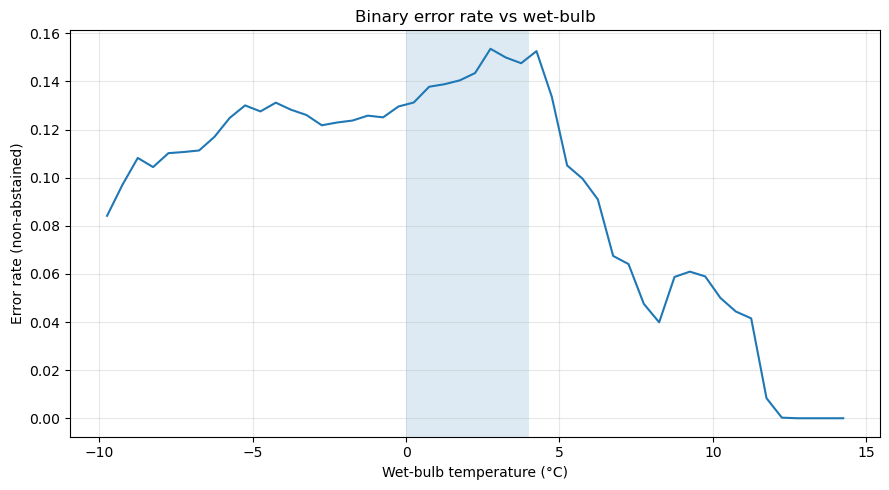

In [46]:
# Error rate vs wet-bulb (non-abstained only)

df_test["error"] = False
mask_keep = df_test["abstain"] == False
df_test.loc[mask_keep, "error"] = (
    y_pred_abst[mask_keep] != y_test.values[mask_keep]
)

error_rate_by_tw = (
    df_test.groupby("tw_bin")["error"]
    .mean()
)

plt.figure(figsize=(9,5))
plt.plot(bin_mids, error_rate_by_tw.values)
plt.axvspan(0,4, alpha=0.15)
plt.xlabel("Wet-bulb temperature (°C)")
plt.ylabel("Error rate (non-abstained)")
plt.title("Binary error rate vs wet-bulb")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
mask_keep = (y_pred_abst != 2)

cm = confusion_matrix(
    y_test.values[mask_keep],
    y_pred_abst[mask_keep],
    labels=[0,1]
)

print("Confusion matrix (rows=true [snow,rain], cols=pred [snow,rain]):")
print(cm)

print("\nClassification report (non-abstained only):")
print(classification_report(
    y_test.values[mask_keep],
    y_pred_abst[mask_keep],
    target_names=["snow","rain"],
    digits=3
))

print("\nF1 (snow):", f1_score(y_test.values[mask_keep], y_pred_abst[mask_keep], pos_label=0))
print("F1 (rain):", f1_score(y_test.values[mask_keep], y_pred_abst[mask_keep], pos_label=1))


Confusion matrix (rows=true [snow,rain], cols=pred [snow,rain]):
[[1063392  172313]
 [ 196128 1177684]]

Classification report (non-abstained only):
              precision    recall  f1-score   support

        snow      0.844     0.861     0.852   1235705
        rain      0.872     0.857     0.865   1373812

    accuracy                          0.859   2609517
   macro avg      0.858     0.859     0.859   2609517
weighted avg      0.859     0.859     0.859   2609517


F1 (snow): 0.8523415724032903
F1 (rain): 0.864733173287848


In [48]:
abstention_rate = np.mean(y_pred_abst == 2)
coverage = 1 - abstention_rate

print(f"Abstention rate: {abstention_rate:.3f}")
print(f"Coverage: {coverage:.3f}")


Abstention rate: 0.121
Coverage: 0.879


In [ ]:
brier = brier_score_loss(y_test.values, p_rain)
print("Overall Brier score (rain):", brier)

brier_snow = brier_score_loss(
    (y_test.values == 0).astype(int),
    p_snow
)

brier_rain = brier_score_loss(
    (y_test.values == 1).astype(int),
    p_rain
)

print("Brier (snow):", brier_snow)
print("Brier (rain):", brier_rain)


Overall Brier score (rain): 0.12566439401232127
Brier (snow): 0.1256643940052948
Brier (rain): 0.12566439401232127


In [51]:
df_test["p_rain"] = p_rain
df_test["p_snow"] = p_snow
df_test["prediction"] = y_pred_abst
df_test["max_prob"] = max_prob

df_test.groupby("phase")[["p_snow","p_rain"]].mean()


,p_snow,p_rain
phase,,
0.0,0.744111,0.255889
1.0,0.247402,0.752598


In [ ]:
probs = np.vstack([p_snow, p_rain])
df_test["entropy"] = entropy(probs, base=2)

df_test["entropy"].describe()


count    2.969590e+06
mean     5.647699e-01
std      3.253646e-01
min      0.000000e+00
25%      2.795969e-01
50%      5.895136e-01
75%      8.802133e-01
max      1.000000e+00
Name: entropy, dtype: float64

In [ ]:
# Export and Save

model_path = MODEL_OUT_DIR / "xgb_phase_model.bin"
booster.save_model(model_path)

feature_names = list(X_train.columns)

with open(MODEL_OUT_DIR / "feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)

# Predictors matrix "X_test"
X_test.to_parquet(MODEL_OUT_DIR / "X_test.parquet")
for col in X_test.columns:
    dtype = X_test[col].dtype
    print(f"X_test parquet contains: {col:25s} | {dtype}")

# Ground truth labels of phase "y_test" (observed)
y_test.to_frame(name="phase_bin").to_parquet(
    MODEL_OUT_DIR / "y_test.parquet"
)

# Predictions output!
df_test_out = df_test[
    [
        "time",
        "x",
        "y",
        "phase",
        "prediction",
        "p_snow",
        "p_rain",
        "max_prob",
        "entropy",
        "block_id"
    ]
]
for col in df_test_out.columns:
    dtype = df_test_out[col].dtype
    print(f"test_predictions parquet contains: {col:25s} | {dtype}")
    
df_test_out.to_parquet(
    MODEL_OUT_DIR / "test_predictions.parquet"
)


metadata = {
    "classes": {
        "0": "snow",
        "1": "rain",
        "2": "uncertain/mix (abstention)"
    },
    "model_type": "XGBoost (binary:logistic + abstention)",
    "confidence_threshold": 0.6,
    "spatial_blocking": "random block split (~25–50 km blocks)",
    "training_period": "2024-10-11 to 2025-05-30",
    "label_definition": {
        "snow": "proxy <= 20",
        "rain": "proxy >= 80",
        "ambiguous": "excluded from training"
    },
    "transition_weighting": "applied to 0–4°C wet-bulb",
    "notes": "Binary classification with uncertainty region to represent transition zone"
}

with open(MODEL_OUT_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_8216\973343573.py:4: UserWarning: [11:36:53] WARNING: D:\bld\xgboost-split_1765326876395\work\src\c_api\c_api.cc:1575: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  booster.save_model(model_path)


X_test parquet contains: temp_wet                  | float32
X_test parquet contains: temp_dew                  | float32
X_test parquet contains: rh                        | float32
X_test parquet contains: imerg_plp                 | float64
X_test parquet contains: elev                      | float32
X_test parquet contains: t_air_anom                | float64
test_predictions parquet contains: time                      | datetime64[ns]
test_predictions parquet contains: x                         | float64
test_predictions parquet contains: y                         | float64
test_predictions parquet contains: phase                     | float64
test_predictions parquet contains: prediction                | int64
test_predictions parquet contains: p_snow                    | float32
test_predictions parquet contains: p_rain                    | float32
test_predictions parquet contains: max_prob                  | float32
test_predictions parquet contains: entropy                   

In [ ]:
y